# Teaching demo: Samples, Estimates, and p-values

Companion notebook for **Barrett_DAIS.pptx**.

We use a synthetic ED-cost dataset (`ed_costs.csv`, n = 1,000) to illustrate:

1. Loading and exploring data
2. Point estimates & confidence intervals (OLS)
3. A p-value from **statistical theory** (the t-distribution)
4. A p-value from **simulation** (permutation test)
5. Bonus 1: bootstrap confidence interval
6. Bonus 2: simulating directly from the NULL world
7. Bonus 3: what happens as the sample size changes

The data columns are:

| column       | meaning                                          |
|--------------|--------------------------------------------------|
| `patient_id` | unique id                                        |
| `food_insec` | food insecurity flag (0/1)                       |
| `income`     | household income ($)                             |
| `comorbid`   | comorbidity count                                |
| `transport`  | transportation access (0/1)                      |
| `ed_cost`    | monthly ED cost ($) — the outcome                |


## Notes Section

Add Notes here

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:,.2f}".format)
np.random.seed(42)

df = pd.read_csv("ed_costs.csv")
df.head()

Matplotlib is building the font cache; this may take a moment.


,patient_id,food_insec,income,comorbid,transport,ed_cost
0,1,0,50109,0,1,0.00
1,2,1,48990,0,0,"4,549.08"
2,3,1,58566,2,1,550.29
3,4,1,65205,0,1,0.00
4,5,0,50912,2,0,229.09


## 1. Peek at the data

Before any modeling, look at shape, missingness, and a quick by-group comparison.

In [2]:
print("shape:", df.shape)
print("missing per column:")
print(df.isna().sum())
df.describe()

shape: (1000, 6)
missing per column:
patient_id    0
food_insec    0
income        0
comorbid      0
transport     0
ed_cost       0
dtype: int64


,patient_id,food_insec,income,comorbid,transport,ed_cost
count,"1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00"
mean,500.50,0.29,"59,786.60",1.22,0.76,"1,763.95"
std,288.82,0.45,"21,696.94",1.09,0.43,"2,156.67"
min,1.00,0.00,"12,000.00",0.00,0.00,0.00
25%,250.75,0.00,"45,207.75",0.00,1.00,0.00
50%,500.50,0.00,"59,108.00",1.00,1.00,927.67
75%,750.25,1.00,"73,838.75",2.00,1.00,"2,982.04"
max,"1,000.00",1.00,"133,732.00",6.00,1.00,"10,736.72"


In [3]:
# Mean ED cost by food-insecurity status
df.groupby("food_insec")["ed_cost"].agg(["count", "mean", "std"])

,count,mean,std
food_insec,,,
0,710,"1,658.66","2,107.62"
1,290,"2,021.72","2,255.34"


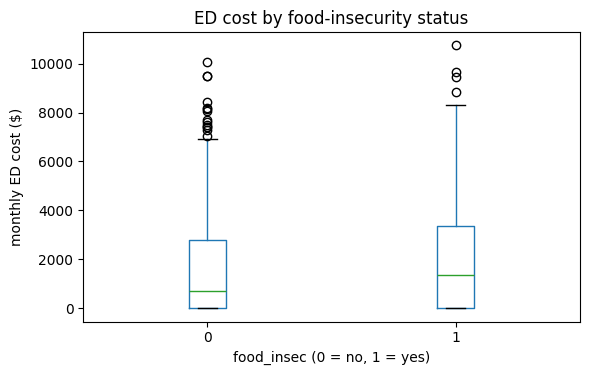

In [4]:
# Quick visualization — distribution of ED cost by food-insecurity flag
fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column="ed_cost", by="food_insec", ax=ax, grid=False)
ax.set_title("ED cost by food-insecurity status")
ax.set_xlabel("food_insec (0 = no, 1 = yes)")
ax.set_ylabel("monthly ED cost ($)")
plt.suptitle("")  # suppress the default suptitle
plt.tight_layout()
plt.show()

## 2. Statistical theory — the p-value from OLS

This is the code from the **Statistical Theory** slide. The p-value comes from
the t-distribution with `n - k - 1` degrees of freedom.

In [5]:
fx  = "ed_cost ~ food_insec + income"
fit = smf.ols(fx, data=df).fit()

print(fit.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1975.9231    204.757      9.650      0.000    1574.120    2377.727
food_insec   358.5615    149.820      2.393      0.017      64.562     652.561
income        -0.0053      0.003     -1.686      0.092      -0.011       0.001


In [6]:
# Pull out the pieces by name
coef = fit.params["food_insec"]
se   = fit.bse["food_insec"]
t    = fit.tvalues["food_insec"]
p    = fit.pvalues["food_insec"]
ci_l, ci_h = fit.conf_int().loc["food_insec"]

print(f"estimate = ${coef:,.2f}")
print(f"SE       = ${se:,.2f}")
print(f"t        = {t:.3f}")
print(f"p-value  = {p:.4f}")
print(f"95% CI   = (${ci_l:,.2f}, ${ci_h:,.2f})")

estimate = $358.56
SE       = $149.82
t        = 2.393
p-value  = 0.0169
95% CI   = ($64.56, $652.56)


## 3. Simulation — the p-value from a permutation test

This is the code from the **Simulate It** slide. We shuffle the predictor
thousands of times to build the null distribution ourselves — no t-distribution
needed.

In [7]:
obs = smf.ols(fx, data=df).fit().params["food_insec"]

rng  = np.random.default_rng(42)
null = np.empty(5000)
for i in range(5000):
    shuf    = df.assign(food_insec=rng.permutation(df.food_insec))
    null[i] = smf.ols(fx, data=shuf).fit().params["food_insec"]

p_sim = ((np.abs(null) >= abs(obs)).sum() + 1) / (len(null) + 1)
print(f"observed coef  = ${obs:,.2f}")
print(f"simulated p    = {p_sim:.4f}")

observed coef  = $358.56
simulated p    = 0.0160


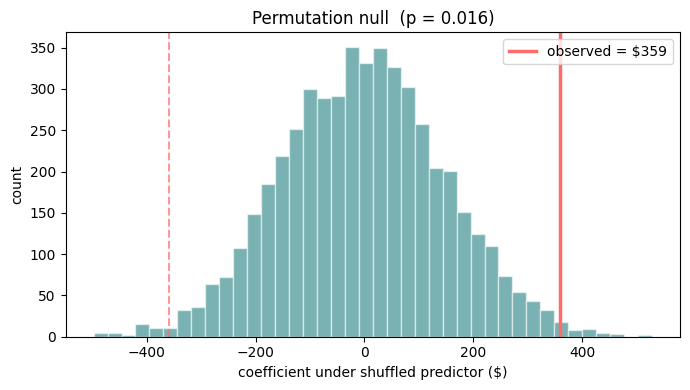

In [8]:
# Plot the simulated null vs. the observed
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(null, bins=40, color="#0D7377", alpha=0.55, edgecolor="white")
ax.axvline(obs,  color="#FF6B6B", linewidth=2.5, label=f"observed = ${obs:,.0f}")
ax.axvline(-obs, color="#FF6B6B", linewidth=1.5, linestyle="--", alpha=0.7)
ax.set_xlabel("coefficient under shuffled predictor ($)")
ax.set_ylabel("count")
ax.set_title(f"Permutation null  (p = {p_sim:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Bonus — bootstrap confidence interval

The permutation test gave us a p-value. The **bootstrap** gives us an interval
for the estimate itself. Resample *with replacement* and refit many times;
the 2.5–97.5 percentile of the bootstrap coefficients is a 95% CI.

In [9]:
rng = np.random.default_rng(1)
B = 2000
boot = np.empty(B)
n = len(df)
for b in range(B):
    idx = rng.integers(0, n, size=n)
    samp = df.iloc[idx]
    boot[b] = smf.ols(fx, data=samp).fit().params["food_insec"]

lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"bootstrap estimate (mean) = ${boot.mean():,.2f}")
print(f"95% bootstrap CI          = (${lo:,.2f}, ${hi:,.2f})")
print(f"compare to OLS 95% CI     = (${ci_l:,.2f}, ${ci_h:,.2f})")

bootstrap estimate (mean) = $358.99
95% bootstrap CI          = ($73.48, $662.08)
compare to OLS 95% CI     = ($64.56, $652.56)


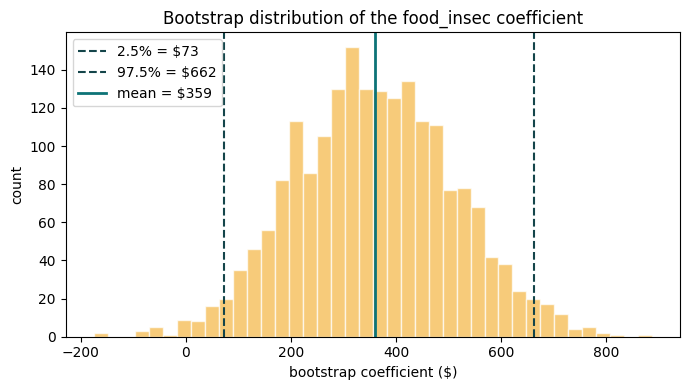

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(boot, bins=40, color="#F5B642", alpha=0.7, edgecolor="white")
ax.axvline(lo, color="#14454A", linestyle="--", label=f"2.5% = ${lo:,.0f}")
ax.axvline(hi, color="#14454A", linestyle="--", label=f"97.5% = ${hi:,.0f}")
ax.axvline(boot.mean(), color="#0D7377", linewidth=2, label=f"mean = ${boot.mean():,.0f}")
ax.set_xlabel("bootstrap coefficient ($)")
ax.set_ylabel("count")
ax.set_title("Bootstrap distribution of the food_insec coefficient")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Bonus — simulate directly from the NULL world

Another way to build the null: keep the real predictors but generate
`ed_cost` from a world where `food_insec` has *no* effect. This makes the
NULL slide's idea very concrete.

In [13]:
# Fit a model WITHOUT food_insec to get realistic residual sd and baseline
fit_null_model = smf.ols("ed_cost ~ income", data=df).fit()
resid_sd       = np.std(fit_null_model.resid, ddof=fit_null_model.df_resid > 0)
beta_income    = fit_null_model.params["income"]
intercept      = fit_null_model.params["Intercept"]

rng  = np.random.default_rng(7)
null_draws = np.empty(5000)
for i in range(5000):
    sim_cost = (intercept
                + beta_income * df["income"]
                + rng.normal(0, resid_sd, size=len(df)))
    sim_df   = df.assign(ed_cost=sim_cost)
    null_draws[i] = smf.ols(fx, data=sim_df).fit().params["food_insec"]

p_null = ((np.abs(null_draws) >= abs(obs)).sum() + 1) / (len(null_draws) + 1)
print(f"p-value from 'simulate-from-H0' = {p_null:.4f}")

p-value from 'simulate-from-H0' = 0.0184


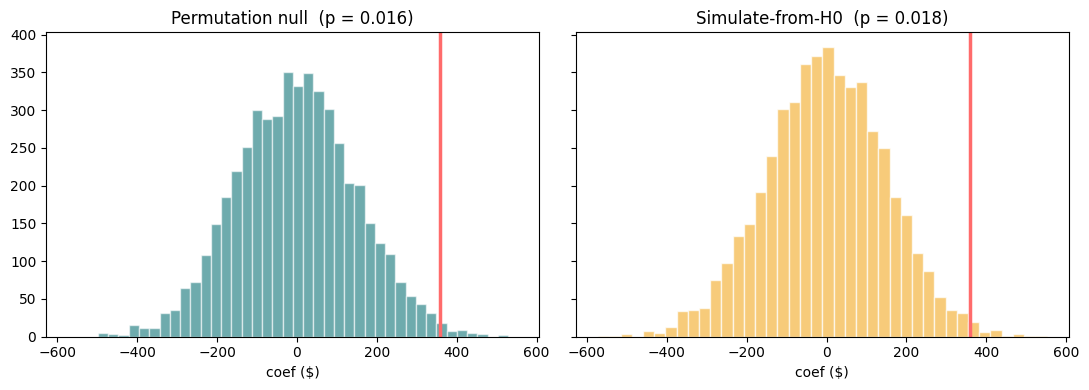

In [ ]:
# Compare null distributions visually
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
axes[0].hist(null, bins=40, color="#0D7377", alpha=0.6, edgecolor="white")
axes[0].axvline(obs, color="#FF6B6B", linewidth=2.5)
axes[0].set_title(f"Permutation null  (p = {p_sim:.3f})")
axes[0].set_xlabel("coef ($)")

axes[1].hist(null_draws, bins=40, color="#F5B642", alpha=0.7, edgecolor="white")
axes[1].axvline(obs, color="#FF6B6B", linewidth=2.5)
axes[1].set_title(f"Simulate-from-H0  (p = {p_null:.3f})")
axes[1].set_xlabel("coef ($)")

plt.tight_layout()
plt.show()

## 6. Bonus — what happens as sample size changes?

The population effect is fixed — but our **estimate** has more or less
uncertainty depending on the sample size we draw. This ties the "sampling"
intuition from slides 16–17 to the p-value.

In [15]:
rng = np.random.default_rng(2026)
rows = []
for n_size in [50, 100, 250, 500, 1000]:
    ests, ps = [], []
    for _ in range(200):
        samp = df.sample(n=n_size, replace=False, random_state=rng.integers(0, 10**9))
        f = smf.ols(fx, data=samp).fit()
        ests.append(f.params["food_insec"])
        ps.append(f.pvalues["food_insec"])
    rows.append({
        "n": n_size,
        "mean est": np.mean(ests),
        "SD of est": np.std(ests, ddof=1),
        "% p<0.05": np.mean(np.array(ps) < 0.05) * 100,
    })
pd.DataFrame(rows)

,n,mean est,SD of est,% p<0.05
0,50,315.90,633.04,5.00
1,100,369.06,449.28,11.00
2,250,350.95,246.66,18.50
3,500,360.11,150.48,31.00
4,1000,358.56,0.00,100.00


Notice:

- The **mean estimate** stays near the true effect (~$350) at every size.
- The **SD of the estimate** (and the width of the CI) shrinks as n grows.
- The **power** (the % of samples where we reject H0 at α=0.05) climbs with n.

That's the whole story of samples, estimates, and p-values in one table.